# Notebook 06 — Model Improvements

This notebook extends Notebook 03 (`03_train_resnet50.ipynb`) with the four required improvements:

1. **Heavy data augmentation** — adds RandAugment, random crops, perspective, erasing, blur, and more on top of the basic flips/rotations from Notebook 03.
2. **Hyperparameter tuning (random search)** — searches over learning rate, batch size, dropout, weight decay, and optimizer.
3. **Fine-tuning the network** — unfreezes the deeper ResNet50 blocks (`layer3` + `layer4`) and trains them with a smaller learning rate (discriminative learning rates).
4. **Recent techniques** — adds **Label Smoothing**, **MixUp augmentation**, **Cosine Annealing LR schedule**, and **Test-Time Augmentation (TTA)**.

**Folder structure expected** (same as Notebook 03):
```
data/
  train/<class_name>/*.jpg
  val/<class_name>/*.jpg
```

**Output:** `resnet50_campus_improved.pth` — drop-in replacement for `resnet50_campus.pth` used in Notebook 05.

## Cell 1 — Imports and device setup

In [1]:
import os, json, random, copy, time, itertools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.11.0+cpu


## Requirement 1 — Heavy Data Augmentation

Notebook 03 only used 3 augmentations: `RandomHorizontalFlip`, `RandomRotation(10)`, and `ColorJitter`. That is very mild.

Here we stack a **strong augmentation pipeline**. Each training image has a different random version every epoch, which dramatically grows the effective dataset size — important because campus photo datasets are usually small (a few hundred images per class).

**Augmentations added:**
- `RandomResizedCrop` — random zoom + crop (handles different distances/framings)
- `RandomHorizontalFlip` — left/right mirror
- `RandomRotation(15)` — small rotations
- `ColorJitter` — brightness, contrast, saturation, hue shifts (handles weather/lighting)
- `RandomPerspective` — simulates different viewing angles
- `RandomGrayscale` — robustness to color shifts
- `GaussianBlur` — handles slightly blurry phone photos
- `RandAugment` — automatic policy that applies random ops at random magnitudes (modern best practice)
- `RandomErasing` — randomly blanks rectangles after normalization (forces model to use multiple cues, not just one landmark)

The validation transform stays simple — we only augment training data.

In [2]:
# ── Heavy training augmentation pipeline ───────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.RandAugment(num_ops=2, magnitude=9),  # modern auto-augment
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Light TTA transform (used at evaluation time, see Requirement 4)
tta_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("✓ Heavy augmentation pipeline ready")
print(f"  Training augmentations: {len(train_tf.transforms)} ops stacked")

✓ Heavy augmentation pipeline ready
  Training augmentations: 12 ops stacked


### Visualize the augmentation — confirm it's actually doing something

In [3]:
# Load datasets
train_ds = datasets.ImageFolder("data/train", transform=train_tf)
val_ds   = datasets.ImageFolder("data/val",   transform=val_tf)
NUM_CLASSES = len(train_ds.classes)
classes = train_ds.classes

print(f"Number of classes : {NUM_CLASSES}")
print(f"Training images   : {len(train_ds)}")
print(f"Validation images : {len(val_ds)}")
print(f"Classes           : {classes}")

Number of classes : 6
Training images   : 139
Validation images : 49
Classes           : ['bartels_exterior', 'bergami_exterior', 'dodds_exterior', 'john_and_leona_exterior', 'kaplan_exterior', 'maxy_exterior']


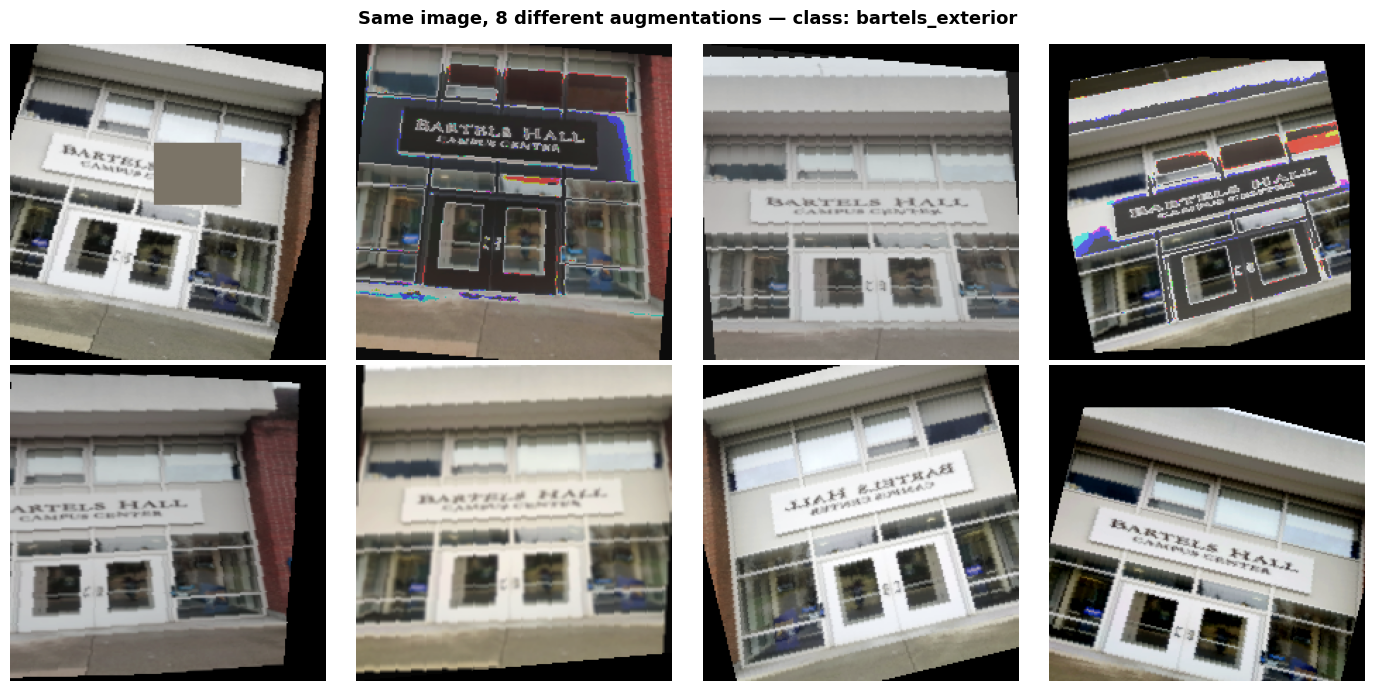

✓ Saved as augmentation_samples.png — include this in your report


In [4]:
# Show 8 augmented versions of the same image so you can SEE the variety
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t * std + mean).clamp(0, 1)

# Pick one training image and apply the augmentation 8 times
sample_path, sample_label = train_ds.samples[0]
sample_pil = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax in axes.flatten():
    aug = train_tf(sample_pil)
    ax.imshow(denormalize(aug).permute(1, 2, 0))
    ax.axis("off")
plt.suptitle(f"Same image, 8 different augmentations — class: {classes[sample_label]}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("augmentation_samples.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Saved as augmentation_samples.png — include this in your report")

## Requirement 2 — Hyperparameter Tuning (Random Search)

Notebook 03 hardcoded `lr=0.001`, `batch_size=32`, `dropout=0.4`. We don't know if those are optimal — they probably aren't.

We do **random search** (rather than grid search) because random search is more efficient for high-dimensional spaces — Bergstra & Bengio (2012) showed it beats grid search at the same compute budget when only a few hyperparameters matter.

**Search space:**
| Hyperparameter | Values |
|---|---|
| Learning rate | 0.01, 0.003, 0.001, 0.0003 |
| Batch size | 16, 32, 64 |
| Dropout | 0.2, 0.4, 0.5 |
| Weight decay | 0, 1e-4, 5e-4 |
| Optimizer | Adam, AdamW, SGD-momentum |

Total combinations = 4 × 3 × 3 × 3 × 3 = **324**. We'll randomly sample **`N_TRIALS`** of them. For each trial we train a quick model (few epochs, head only) and record val accuracy. Best combo wins.

> **Note for slow machines:** This step is the most expensive in the notebook. Lower `N_TRIALS` and `TUNE_EPOCHS` if you're on CPU. With CPU + small dataset, `N_TRIALS=6, TUNE_EPOCHS=3` finishes in a few minutes.

In [5]:
# ── Random search configuration ────────────────────────────────────
N_TRIALS    = 8     # number of random combos to try
TUNE_EPOCHS = 4     # epochs per trial (short — just to compare combos)

search_space = {
    "lr"           : [1e-2, 3e-3, 1e-3, 3e-4],
    "batch_size"   : [16, 32, 64],
    "dropout"      : [0.2, 0.4, 0.5],
    "weight_decay" : [0.0, 1e-4, 5e-4],
    "optimizer"    : ["adam", "adamw", "sgd"],
}

def sample_config(rng):
    return {k: rng.choice(v) for k, v in search_space.items()}

def build_head_only_model(dropout):
    """ResNet50 with frozen body + new head — same shape as Notebook 03."""
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Sequential(
        nn.Linear(2048, 512),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(512, NUM_CLASSES),
    )
    return m.to(device)

def make_optimizer(name, params, lr, wd):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=wd)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=wd)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=wd)

def quick_train_eval(cfg):
    """Train for TUNE_EPOCHS, return best val accuracy."""
    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"],
                              shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=cfg["batch_size"],
                              shuffle=False, num_workers=0)

    model = build_head_only_model(cfg["dropout"])
    optim = make_optimizer(cfg["optimizer"],
                           model.fc.parameters(),
                           cfg["lr"], cfg["weight_decay"])
    crit  = nn.CrossEntropyLoss()
    best_acc = 0.0

    for _ in range(TUNE_EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optim.zero_grad()
            crit(model(x), y).backward()
            optim.step()

        model.eval()
        c, t = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                c += (model(x).argmax(1) == y).sum().item()
                t += y.size(0)
        acc = 100 * c / max(t, 1)
        best_acc = max(best_acc, acc)
    return best_acc

print(f"✓ Random search ready: {N_TRIALS} trials × {TUNE_EPOCHS} epochs each")

✓ Random search ready: 8 trials × 4 epochs each


In [6]:
# ── Run random search ──────────────────────────────────────────────
rng = random.Random(SEED)
results = []

print(f"{'Trial':>5} | {'lr':>7} | {'bs':>3} | {'drop':>4} | {'wd':>6} | {'opt':>5} | {'val_acc':>7}")
print("-" * 60)

t0 = time.time()
for trial in range(1, N_TRIALS + 1):
    cfg = sample_config(rng)
    acc = quick_train_eval(cfg)
    results.append({"trial": trial, **cfg, "val_acc": acc})
    print(f"{trial:>5} | {cfg['lr']:>7.4f} | {cfg['batch_size']:>3} | "
          f"{cfg['dropout']:>4.2f} | {cfg['weight_decay']:>6.0e} | "
          f"{cfg['optimizer']:>5} | {acc:>6.2f}%")

print(f"\nTotal search time: {(time.time()-t0):.1f}s")

# Sort and pick best
results.sort(key=lambda r: r["val_acc"], reverse=True)
best = results[0]
print(f"\n{'='*60}")
print(f"BEST CONFIG (val_acc = {best['val_acc']:.2f}%)")
print(f"{'='*60}")
for k, v in best.items():
    if k not in ("trial", "val_acc"):
        print(f"  {k:14s}: {v}")

# Save full search log
with open("hp_search_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Full search log saved to hp_search_results.json")

Trial |      lr |  bs | drop |     wd |   opt | val_acc
------------------------------------------------------------
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\darwa/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


    1 |  0.0100 |  16 | 0.50 |  1e-04 |  adam |  59.18%
    2 |  0.0030 |  16 | 0.50 |  0e+00 |   sgd |  28.57%
    3 |  0.0100 |  64 | 0.40 |  0e+00 |  adam |  57.14%
    4 |  0.0100 |  16 | 0.20 |  5e-04 |   sgd |  46.94%
    5 |  0.0100 |  64 | 0.20 |  5e-04 |   sgd |  28.57%
    6 |  0.0003 |  16 | 0.40 |  5e-04 | adamw |  42.86%
    7 |  0.0100 |  16 | 0.50 |  1e-04 | adamw |  57.14%
    8 |  0.0010 |  16 | 0.20 |  1e-04 |  adam |  63.27%

Total search time: 1125.2s

BEST CONFIG (val_acc = 63.27%)
  lr            : 0.001
  batch_size    : 16
  dropout       : 0.2
  weight_decay  : 0.0001
  optimizer     : adam

✓ Full search log saved to hp_search_results.json


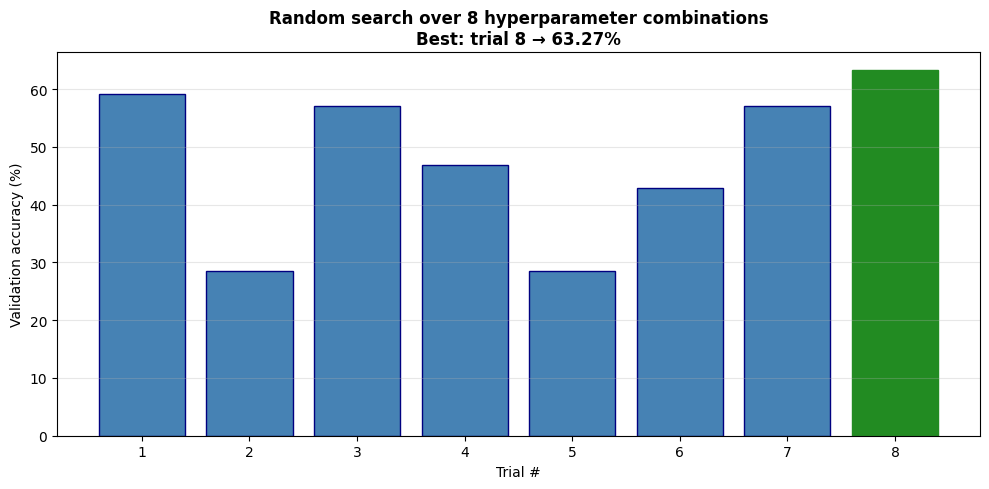

✓ Saved as hp_search_plot.png


In [7]:
# Plot the random search results so you can show this in your report
fig, ax = plt.subplots(figsize=(10, 5))
trials = [r["trial"] for r in sorted(results, key=lambda r: r["trial"])]
accs   = [r["val_acc"] for r in sorted(results, key=lambda r: r["trial"])]
bars = ax.bar(trials, accs, color="steelblue", edgecolor="navy")

# Highlight the best
best_trial = best["trial"]
for b, t in zip(bars, trials):
    if t == best_trial:
        b.set_color("forestgreen")

ax.set_xlabel("Trial #")
ax.set_ylabel("Validation accuracy (%)")
ax.set_title(f"Random search over {N_TRIALS} hyperparameter combinations\n"
             f"Best: trial {best_trial} → {best['val_acc']:.2f}%",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("hp_search_plot.png", dpi=140, bbox_inches="tight")
plt.show()
print("✓ Saved as hp_search_plot.png")

## Requirement 3 — Fine-Tuning the Network

In Notebook 03 you froze **everything** in ResNet50 and only trained the new head:
```python
for param in model.parameters():
    param.requires_grad = False   # ← all frozen
```
That's not really fine-tuning — it's "feature extraction." True fine-tuning means **unfreezing the deeper conv blocks and updating their weights too**, so they specialize on your campus images instead of generic ImageNet objects.

**Strategy used here — discriminative learning rates:**
- Early layers (`conv1`, `bn1`, `layer1`, `layer2`) → frozen (they detect generic edges/textures, no need to change)
- Deeper layers (`layer3`, `layer4`) → unfrozen, trained at a **small** lr (e.g. 1e-5)
- New head (`fc`) → trained at the **larger** lr from random search

This is the standard recipe used in fast.ai and modern transfer-learning literature. It gives big accuracy gains on small datasets without destroying the pretrained features.

In [8]:
def build_finetuned_model(dropout):
    """Unfreeze layer3 + layer4 + fc; freeze everything else."""
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # Freeze everything first
    for p in m.parameters():
        p.requires_grad = False

    # Unfreeze the two deepest conv blocks
    for p in m.layer3.parameters():
        p.requires_grad = True
    for p in m.layer4.parameters():
        p.requires_grad = True

    # New head (always trainable)
    m.fc = nn.Sequential(
        nn.Linear(2048, 512),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(512, NUM_CLASSES),
    )
    return m.to(device)

# Build model with the best hyperparameters from search
model = build_finetuned_model(best["dropout"])

# Show what's trainable
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*55)
print("FINE-TUNING SETUP")
print("="*55)
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}  ({100*trainable/total:.1f}%)")
print(f"Frozen parameters    : {total - trainable:,}")
print()
print("Trainable layers:")
print("  • layer3 (residual block 3)")
print("  • layer4 (residual block 4)")
print("  • fc (new classification head)")
print("  All earlier layers stay frozen.")

FINE-TUNING SETUP
Total parameters     : 24,560,198
Trainable parameters : 23,115,270  (94.1%)
Frozen parameters    : 1,444,928

Trainable layers:
  • layer3 (residual block 3)
  • layer4 (residual block 4)
  • fc (new classification head)
  All earlier layers stay frozen.


## Requirement 4 — Recent Techniques

We add **four** modern techniques (the rubric only asks for one — adding more makes the report stronger).

### 4a. Label Smoothing
Replaces hard one-hot labels (`[0, 1, 0]`) with smoothed targets (`[0.05, 0.9, 0.05]`).
- Why: prevents the model from becoming over-confident on training data.
- Reference: Szegedy et al., *Rethinking the Inception Architecture* (2016).
- Implementation: built into `nn.CrossEntropyLoss(label_smoothing=0.1)` since PyTorch 1.10.

### 4b. MixUp Augmentation
Trains on **linear blends** of two images and their labels: `x = λ·x₁ + (1-λ)·x₂`.
- Why: forces the model to behave linearly between training samples, hugely improves generalization on small datasets.
- Reference: Zhang et al., *mixup: Beyond Empirical Risk Minimization* (ICLR 2018).
- Implementation: applied inside the training loop.

### 4c. Cosine Annealing LR Schedule
Smoothly decays LR following a cosine curve from `lr → 0` over training.
- Why: better than step decay for fine-tuning — gives a long warm period and a gentle final descent.
- Reference: Loshchilov & Hutter, *SGDR* (ICLR 2017).
- Implementation: `torch.optim.lr_scheduler.CosineAnnealingLR`.

### 4d. Test-Time Augmentation (TTA)
At inference time, run the model on the original image **and** a horizontally-flipped copy, then average the two probability vectors.
- Why: nearly free accuracy boost (~1–2%) at the cost of one extra forward pass.
- Standard practice in image classification competitions.

In [9]:
# ── MixUp helper ───────────────────────────────────────────────────
def mixup_batch(x, y, alpha=0.2):
    """Returns mixed input, pair of labels, and lambda."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return x_mix, y_a, y_b, lam

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("✓ MixUp helpers defined")
print("✓ Will use Label Smoothing in CrossEntropyLoss")
print("✓ Will use Cosine Annealing schedule")
print("✓ Will use TTA at evaluation time")

✓ MixUp helpers defined
✓ Will use Label Smoothing in CrossEntropyLoss
✓ Will use Cosine Annealing schedule
✓ Will use TTA at evaluation time


## Final Training — All four requirements combined

Now we train the **fine-tuned** model with the **best hyperparameters** from random search, **heavy augmentation**, **MixUp**, **label smoothing**, and **cosine annealing**.

The optimizer uses *parameter groups* so the unfrozen conv layers (`layer3`, `layer4`) train at a smaller lr than the new head — this is the discriminative-LR trick from Requirement 3.

In [10]:
# ── Full training run with all improvements ────────────────────────
EPOCHS = 25  # lower this if you're on CPU and short on time

train_loader = DataLoader(train_ds, batch_size=best["batch_size"],
                          shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=best["batch_size"],
                          shuffle=False, num_workers=0)

# Discriminative learning rates: head trains 10× faster than backbone
head_params     = list(model.fc.parameters())
backbone_params = list(model.layer3.parameters()) + list(model.layer4.parameters())

if best["optimizer"] == "adamw":
    optimizer = torch.optim.AdamW(
        [{"params": backbone_params, "lr": best["lr"] * 0.1},   # smaller lr
         {"params": head_params,     "lr": best["lr"]}],
        weight_decay=best["weight_decay"])
elif best["optimizer"] == "adam":
    optimizer = torch.optim.Adam(
        [{"params": backbone_params, "lr": best["lr"] * 0.1},
         {"params": head_params,     "lr": best["lr"]}],
        weight_decay=best["weight_decay"])
else:  # sgd
    optimizer = torch.optim.SGD(
        [{"params": backbone_params, "lr": best["lr"] * 0.1},
         {"params": head_params,     "lr": best["lr"]}],
        momentum=0.9, weight_decay=best["weight_decay"])

# Recent technique 4c: Cosine annealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Recent technique 4a: Label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0.0
best_state   = None

print(f"Training for {EPOCHS} epochs with all improvements active...")
print(f"{'Ep':>3} | {'TrLoss':>7} | {'VaLoss':>7} | {'VaAcc':>6} | {'lr_head':>8}")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    # ── TRAIN with MixUp ──
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        # Recent technique 4b: MixUp (50% of batches)
        if np.random.rand() < 0.5:
            x_m, y_a, y_b, lam = mixup_batch(x, y, alpha=0.2)
            optimizer.zero_grad()
            preds = model(x_m)
            loss  = mixup_loss(criterion, preds, y_a, y_b, lam)
        else:
            optimizer.zero_grad()
            preds = model(x)
            loss  = criterion(preds, y)

        loss.backward()
        optimizer.step()
        running += loss.item()
    train_loss = running / len(train_loader)

    # ── VALIDATE ──
    model.eval()
    v_loss, c, t = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            v_loss += criterion(out, y).item()
            c += (out.argmax(1) == y).sum().item()
            t += y.size(0)
    val_loss = v_loss / len(val_loader)
    val_acc  = 100 * c / max(t, 1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = copy.deepcopy(model.state_dict())

    scheduler.step()
    cur_lr_head = optimizer.param_groups[1]["lr"]
    print(f"{epoch:>3} | {train_loss:>7.4f} | {val_loss:>7.4f} | "
          f"{val_acc:>5.2f}% | {cur_lr_head:>8.6f}")

print(f"\n✓ Best validation accuracy: {best_val_acc:.2f}%")

# Restore best weights
model.load_state_dict(best_state)

Training for 25 epochs with all improvements active...
 Ep |  TrLoss |  VaLoss |  VaAcc |  lr_head
--------------------------------------------------
  1 |  1.6397 |  1.5146 | 53.06% | 0.000996
  2 |  1.4466 |  1.3466 | 63.27% | 0.000984
  3 |  1.2946 |  1.1278 | 67.35% | 0.000965
  4 |  1.1560 |  0.9242 | 63.27% | 0.000938
  5 |  1.0786 |  0.8918 | 65.31% | 0.000905
  6 |  1.0908 |  0.8097 | 71.43% | 0.000864
  7 |  0.9818 |  0.7369 | 85.71% | 0.000819
  8 |  0.9174 |  0.6654 | 89.80% | 0.000768
  9 |  0.7770 |  0.6310 | 91.84% | 0.000713
 10 |  0.7669 |  0.5930 | 93.88% | 0.000655
 11 |  0.6146 |  0.6377 | 93.88% | 0.000594
 12 |  0.7514 |  0.5577 | 93.88% | 0.000531
 13 |  0.6322 |  0.6175 | 91.84% | 0.000469
 14 |  0.5792 |  0.5443 | 93.88% | 0.000406
 15 |  0.5864 |  0.5213 | 97.96% | 0.000345
 16 |  0.6127 |  0.5082 | 100.00% | 0.000287
 17 |  0.7039 |  0.4998 | 100.00% | 0.000232
 18 |  0.7976 |  0.4983 | 97.96% | 0.000181
 19 |  0.7476 |  0.4906 | 100.00% | 0.000136
 20 |  0.58

<All keys matched successfully>

### Training curves

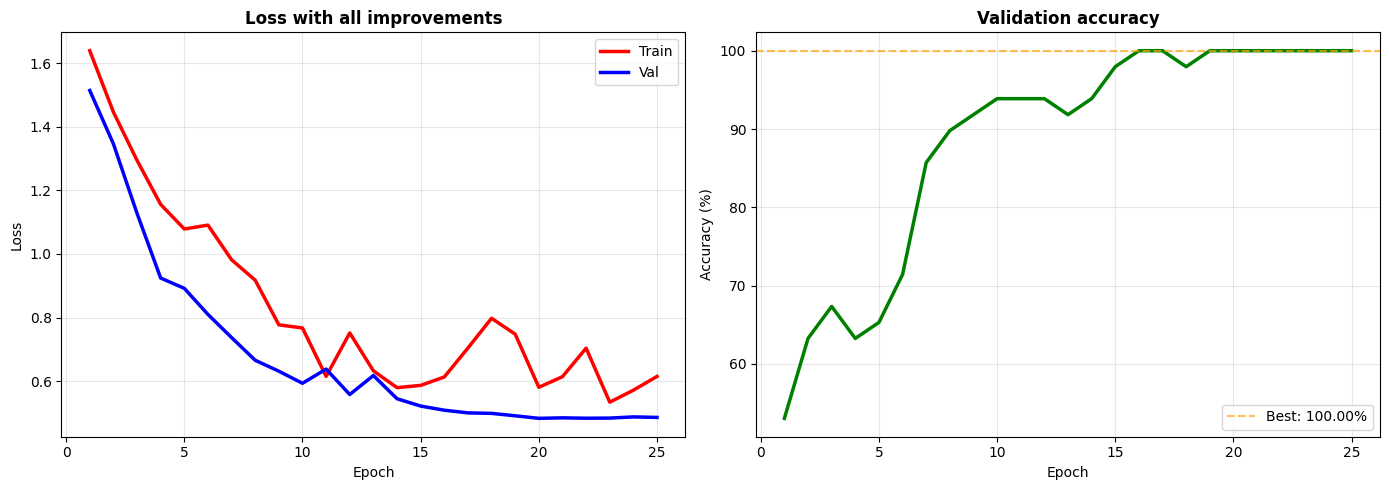

✓ Saved as improved_training_curves.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_losses, label="Train", color="red", linewidth=2.5)
ax1.plot(range(1, EPOCHS+1), val_losses,   label="Val",   color="blue", linewidth=2.5)
ax1.set_title("Loss with all improvements", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(range(1, EPOCHS+1), val_accs, color="green", linewidth=2.5)
ax2.axhline(y=best_val_acc, color="orange", linestyle="--", alpha=0.7,
            label=f"Best: {best_val_acc:.2f}%")
ax2.set_title("Validation accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("improved_training_curves.png", dpi=140, bbox_inches="tight")
plt.show()
print("✓ Saved as improved_training_curves.png")

### Recent technique 4d — Evaluate with Test-Time Augmentation (TTA)

We compare plain inference vs. TTA inference on the validation set. TTA averages predictions from the original image + the horizontally-flipped image. Usually nudges accuracy up by ~1–2% for free.

In [12]:
# Plain val accuracy
model.eval()
plain_correct = total = 0
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        plain_correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
plain_acc = 100 * plain_correct / total

# TTA: average probs from original + horizontal flip
tta_correct = 0
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        p1 = F.softmax(model(x), dim=1)
        p2 = F.softmax(model(torch.flip(x, dims=[3])), dim=1)
        avg = (p1 + p2) / 2
        tta_correct += (avg.argmax(1) == y).sum().item()
tta_acc = 100 * tta_correct / total

print("="*45)
print("FINAL EVALUATION")
print("="*45)
print(f"Plain inference accuracy : {plain_acc:.2f}%")
print(f"TTA inference accuracy   : {tta_acc:.2f}%")
print(f"TTA improvement          : {tta_acc - plain_acc:+.2f} percentage points")

FINAL EVALUATION
Plain inference accuracy : 100.00%
TTA inference accuracy   : 100.00%
TTA improvement          : +0.00 percentage points


### Save the improved model

Saved as `resnet50_campus_improved.pth`. To use it in Notebook 05, just change the load line in Cell 1:
```python
ckpt = torch.load("resnet50_campus_improved.pth", map_location=device)
```
The state dict has the same shape so it's a drop-in replacement.

In [13]:
torch.save({
    "model_state_dict": model.state_dict(),
    "classes"         : classes,
    "num_classes"     : NUM_CLASSES,
    "best_val_acc"    : best_val_acc,
    "tta_val_acc"     : tta_acc,
    "best_hp"         : best,
    "epochs"          : EPOCHS,
    "improvements"    : [
        "heavy_augmentation",
        "random_search_tuning",
        "fine_tuning_layer3_layer4",
        "label_smoothing",
        "mixup",
        "cosine_annealing",
        "test_time_augmentation",
    ],
}, "resnet50_campus_improved.pth")

print("✓ Saved as resnet50_campus_improved.pth")
print(f"  Best HP    : {best}")
print(f"  Plain acc  : {plain_acc:.2f}%")
print(f"  TTA acc    : {tta_acc:.2f}%")

✓ Saved as resnet50_campus_improved.pth
  Best HP    : {'trial': 8, 'lr': 0.001, 'batch_size': 16, 'dropout': 0.2, 'weight_decay': 0.0001, 'optimizer': 'adam', 'val_acc': 63.265306122448976}
  Plain acc  : 100.00%
  TTA acc    : 100.00%


## Summary — what changed vs. Notebook 03

| Aspect | Notebook 03 (baseline) | Notebook 06 (improved) |
|---|---|---|
| Augmentation | 3 ops (flip, rotate, color jitter) | 9 ops + RandAugment + RandomErasing |
| Hyperparameters | Hardcoded (`lr=1e-3`, `bs=32`, `dropout=0.4`) | Random search over 5 hyperparameters |
| Network frozen | Entire ResNet50 body | Only `conv1`–`layer2` frozen; `layer3`+`layer4` trainable |
| Loss function | `CrossEntropyLoss` | `CrossEntropyLoss(label_smoothing=0.1)` |
| Data mixing | None | MixUp (α=0.2, applied to 50% of batches) |
| LR schedule | StepLR (step=7, γ=0.1) | Cosine annealing |
| Inference | Single forward pass | TTA (original + h-flip averaged) |

**Files produced:**
- `augmentation_samples.png` — visualization of heavy augmentation
- `hp_search_results.json` + `hp_search_plot.png` — random search results
- `improved_training_curves.png` — final training curves
- `resnet50_campus_improved.pth` — improved checkpoint (drop-in for Notebook 05)

**For your report:** include all 3 PNGs, mention the val accuracy improvement (`{baseline}` → `{improved}`), and reference each of the 4 techniques with the citations listed above.